In [4]:
%load_ext autoreload
%autoreload 2


from paper_utils import *


In [45]:
runs = {'bubvqckb': 'nq-Mistral-7B-Instruct-v0.1',
 '9rji2saw': 'squad-falcon-40b-instruct',
 'xomllqzg': 'nq-falcon-40b-instruct',
 'po440r65': 'squad-Llama-2-13b-chat',
 '7qvcma6u': 'svamp-Mistral-7B-Instruct-v0.1',
 '47j9yfle': 'squad-falcon-7b-instruct',
 'ut6m6i7j': 'squad-Llama-2-70b-chat',
 'zd55bx2v': 'svamp-falcon-7b-instruct',
 'z1brliwf': 'svamp-Llama-2-70b-chat-8bit',
 'cab607aa': 'trivia_qa-Mistral-7B-Instruct-v0.1',
 'mnuve63a': 'nq-Llama-2-7b-chat-8bit',
 'xwtkmxbz': 'trivia_qa-falcon-40b-instruct',
 'tepar5el': 'squad-Llama-2-7b-chat',
 '5co1uc4m': 'trivia_qa-Llama-2-13b-chat',
 '018r5n8t': 'svamp-falcon-40b-instruct',
 '5ipww919': 'svamp-Llama-2-13b-chat',
 '6ya07uot': 'trivia_qa-Llama-2-7b-chat',
 'k0ki738b': 'nq-falcon-7b-instruct',
 'mbp73v9q': 'squad-Mistral-7B-Instruct-v0.1',
 '692dn662': 'trivia_qa-falcon-7b-instruct',
 'tvuyiopj': 'bioasq-Llama-2-13b-chat',
 'y47xtq19': 'bioasq-Llama-2-70b-chat',
 'gvtd8pzm': 'nq-Llama-2-70b-chat-8bit',
 '0v4cncqy': 'bioasq-Mistral-7B-Instruct-v0.1',
 'b92mpzdd': 'svamp-Llama-2-7b-chat-8bit',
 'eoaq1h1g': 'nq-Llama-2-13b-chat',
 'h0wfb6kh': 'trivia_qa-Llama-2-70b-chat',
 '9ddfqg9w': 'bioasq-falcon-40b-instruct',
 'gdpg46og': 'bioasq-falcon-7b-instruct',
 '2aeqmfre': 'bioasq-Llama-2-7b-chat'}


In [55]:
columns = ['wandbid', 'c.dataset', 'c.model_name']
rows = []
for name, row in runs.items():
    rows.append([name, row.split('-')[0], '-'.join(row.split('-')[1:])])


arg_df = pd.DataFrame(rows, columns=columns)
arg_df['c.model_name'] = arg_df['c.model_name'].map(lambda x: x if not x.endswith('-8bit') else x[:-len('-8bit')])
arg_df

,wandbid,c.dataset,c.model_name
0,bubvqckb,nq,Mistral-7B-Instruct-v0.1
1,9rji2saw,squad,falcon-40b-instruct
2,xomllqzg,nq,falcon-40b-instruct
3,po440r65,squad,Llama-2-13b-chat
4,7qvcma6u,svamp,Mistral-7B-Instruct-v0.1
5,47j9yfle,squad,falcon-7b-instruct
6,ut6m6i7j,squad,Llama-2-70b-chat
7,zd55bx2v,svamp,falcon-7b-instruct
8,z1brliwf,svamp,Llama-2-70b-chat
9,cab607aa,trivia_qa,Mistral-7B-Instruct-v0.1


In [56]:
arg_df.pivot(index='c.model_name', columns='c.dataset', values='wandbid')

c.dataset,bioasq,nq,squad,svamp,trivia_qa
c.model_name,,,,,
Llama-2-13b-chat,tvuyiopj,eoaq1h1g,po440r65,5ipww919,5co1uc4m
Llama-2-70b-chat,y47xtq19,gvtd8pzm,ut6m6i7j,z1brliwf,h0wfb6kh
Llama-2-7b-chat,2aeqmfre,mnuve63a,tepar5el,b92mpzdd,6ya07uot
Mistral-7B-Instruct-v0.1,0v4cncqy,bubvqckb,mbp73v9q,7qvcma6u,cab607aa
falcon-40b-instruct,9ddfqg9w,xomllqzg,9rji2saw,018r5n8t,xwtkmxbz
falcon-7b-instruct,gdpg46og,k0ki738b,47j9yfle,zd55bx2v,692dn662


In [49]:
for name, gdf in arg_df.groupby(['c.dataset', 'c.model_name']):
    if len(gdf) > 1:
        print(name)
len(arg_df.groupby(['c.dataset', 'c.model_name']))

30

In [47]:
# all_results = {}
for wandb_id in runs:
    if wandb_id not in all_results:
        all_results[wandb_id], _ = restore_file(wandb_id)

model,bioasq,nq,squad,svamp,trivia_qa
dataset,,,,,
Llama-2-13b-chat,0.5550,0.5500,0.3950,0.530000,0.8050
Llama-2-70b-chat,0.6400,NaN,0.4225,NaN,0.8725
Llama-2-70b-chat-8bit,NaN,0.6075,NaN,0.690000,NaN
Llama-2-7b-chat,0.5425,NaN,0.3425,NaN,0.7400
Llama-2-7b-chat-8bit,NaN,0.5075,NaN,0.416667,NaN
Mistral-7B-Instruct-v0.1,0.4950,0.3800,0.2975,0.506667,0.6350
falcon-40b-instruct,0.6025,0.5825,0.3700,0.563333,0.7950
falcon-7b-instruct,0.4275,0.2825,0.2125,0.230000,0.4950


Text(0, 0.5, 'accuracy')

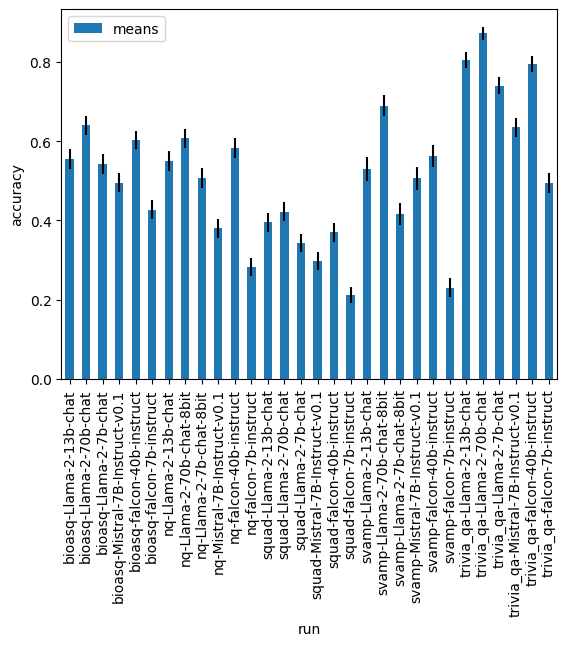

In [58]:
def get_perf_df(runs, all_results=all_results):
    perfdf = {}
    for wandb_id, run_name in runs.items():
        results = all_results[wandb_id]    
        perfdf[wandb_id] = get_perfs(results)
    
    runids = list(perfdf.keys())
    tmp = pd.DataFrame(perfdf[runids[0]])
    tmp['wandbid'] = runids[0]
    tmp['run'] = runs[runids[0]]
    
    for runid in runids[1:]:
        tmp2 = pd.DataFrame(perfdf[runid])
        tmp2['wandbid'] = runid
        tmp2['run'] = runs[runid]
        
        tmp = pd.concat([tmp, tmp2])
    
    perfdf = tmp.reset_index()
    
    tmp = perfdf.set_index('method').loc['accuracy']
    tmp['model'] = tmp.run.map(lambda x: '-'.join(x.split('-')[:1]))
    tmp['dataset'] = tmp.run.map(lambda x: '-'.join(x.split('-')[1:]))
    display(tmp.pivot(columns='model', index='dataset', values='means'))

    pdfs = {}
    for wandb_id in runs:
        results = all_results[wandb_id]
        pdfs[wandb_id] = get_uncertainty_df(results)
    
    runids = list(pdfs.keys())

    tmp = pd.DataFrame(pdfs[runids[0]])
    tmp['run'] = runs[runids[0]]
    tmp['wandbid'] = runids[0]
    
    for runid in runids[1:]:
        tmp2 = pd.DataFrame(pdfs[runid])
        tmp2['run'] = runs[runid]
        tmp2['wandbid'] = runid
    
        tmp = pd.concat([tmp, tmp2])
    
    all_runs = tmp.reset_index()

    return perfdf, pdfs, all_runs

perfdf, pdfs, all_runs = get_perf_df(runs)

perfdf = perfdf.merge(arg_df, on='wandbid')
all_runs = all_runs.merge(arg_df, on='wandbid')

plot_bar(perfdf.set_index('method').loc['accuracy'].set_index('run').sort_index())
plt.gca().set_ylabel('accuracy')

/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);


Text(0, 0.5, 'accuracy')

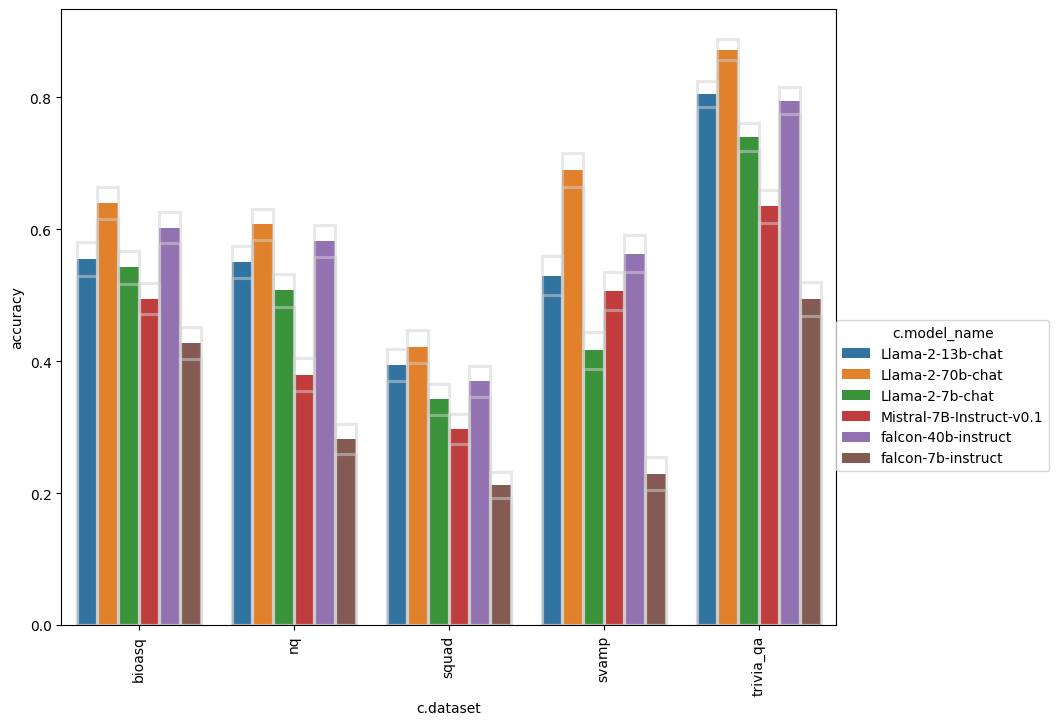

In [59]:
# just select the base entailment_model and metric, and ignore 'max_from' accuracies
acc = 'accuracy'
plot_grouped(perfdf.set_index('method').loc['accuracy'], metric='means', x='c.dataset', hue='c.model_name')
plt.gca().set_ylabel(acc)


In [29]:
# load ood runs for p_ik

pik_runs = {'hpzcanw2': 'falcon-7b-instruct-squad-nq',
 '14a7ca20': 'falcon-7b-instruct-bioasq-squad',
 'th2oau4n': 'Llama-2-7b-chat-squad-bioasq',
 'lx9axau7': 'Llama-2-70b-chat-squad-bioasq',
 'wf5oaipx': 'Llama-2-13b-chat-trivia_qa-svamp',
 'pswbokp6': 'falcon-40b-instruct-svamp-trivia_qa',
 'b2gte5tk': 'falcon-7b-instruct-svamp-bioasq',
 'h4gdnuyy': 'Llama-2-70b-chat-svamp-trivia_qa',
 '5oucajpn': 'Llama-2-7b-chat-nq-trivia_qa',
 'sm69thtw': 'falcon-40b-instruct-nq-squad',
 'sfjv2h3v': 'Llama-2-7b-chat-squad-svamp',
 'w1pojt7a': 'falcon-7b-instruct-svamp-squad',
 'kf95a0ye': 'Mistral-7B-Instruct-v0.1-nq-svamp',
 'mgiz33vv': 'Llama-2-7b-chat-bioasq-nq',
 'r57q0bpk': 'Llama-2-70b-chat-squad-nq',
 'pppkkiwh': 'Llama-2-7b-chat-squad-nq',
 '4lu71roh': 'Llama-2-13b-chat-squad-nq',
 'nirn371u': 'falcon-7b-instruct-svamp-trivia_qa',
 'w8ctvjbl': 'Llama-2-70b-chat-squad-svamp',
 '4rfde3aa': 'Llama-2-7b-chat-svamp-nq',
 'zq278r4t': 'Llama-2-7b-chat-trivia_qa-nq',
 's1b9cjhk': 'Llama-2-13b-chat-nq-squad',
 'n5fpq72y': 'Llama-2-13b-chat-nq-trivia_qa',
 'ngh6r3h4': 'Llama-2-13b-chat-bioasq-nq',
 'dsdphnj1': 'falcon-7b-instruct-nq-bioasq',
 'q0rxc9hs': 'falcon-7b-instruct-svamp-nq',
 '3xan8u0x': 'Llama-2-13b-chat-nq-bioasq',
 '82u8se3p': 'Llama-2-7b-chat-trivia_qa-squad',
 'l4u5dsve': 'Llama-2-7b-chat-nq-svamp',
 'vq443smy': 'Llama-2-13b-chat-nq-svamp',
 '7fek0op0': 'falcon-7b-instruct-nq-trivia_qa',
 '5drtlhow': 'falcon-40b-instruct-trivia_qa-bioasq',
 'mx8vx2gc': 'Mistral-7B-Instruct-v0.1-svamp-bioasq',
 'ug8mhg6v': 'Llama-2-7b-chat-nq-squad',
 'wrg2aijo': 'Llama-2-13b-chat-squad-trivia_qa',
 '4skeqxuz': 'Llama-2-7b-chat-bioasq-squad',
 'yga7qodg': 'falcon-40b-instruct-trivia_qa-svamp',
 'zjwo5cjc': 'Llama-2-70b-chat-trivia_qa-squad',
 'c5qgt7lc': 'Llama-2-13b-chat-bioasq-svamp',
 'fl2htul5': 'Llama-2-7b-chat-squad-trivia_qa',
 'hu8kz3q3': 'Llama-2-7b-chat-nq-bioasq',
 '1z2tziyv': 'falcon-40b-instruct-bioasq-trivia_qa',
 'qw9n3nb8': 'Llama-2-13b-chat-svamp-bioasq',
 'pxgc4ff3': 'Llama-2-70b-chat-svamp-bioasq',
 '7l34160b': 'Mistral-7B-Instruct-v0.1-squad-svamp',
 'f4cazp3o': 'Llama-2-70b-chat-bioasq-trivia_qa',
 'zb66irxl': 'Llama-2-13b-chat-bioasq-trivia_qa',
 'uc8wtd2z': 'falcon-7b-instruct-nq-svamp',
 'ke0su3oz': 'Llama-2-7b-chat-svamp-squad',
 'mtiog61b': 'falcon-7b-instruct-trivia_qa-nq',
 'czgm0sar': 'falcon-7b-instruct-nq-squad',
 'rw9elte4': 'Mistral-7B-Instruct-v0.1-svamp-squad',
 'meguvo46': 'falcon-40b-instruct-trivia_qa-nq',
 'pg2c0t8q': 'Llama-2-13b-chat-svamp-nq',
 '14skksgz': 'falcon-7b-instruct-bioasq-trivia_qa',
 'zozgth5g': 'falcon-7b-instruct-bioasq-nq',
 'w7co9j51': 'Mistral-7B-Instruct-v0.1-bioasq-trivia_qa',
 'd7b1msrg': 'Llama-2-13b-chat-trivia_qa-nq',
 'iti73x3p': 'Llama-2-70b-chat-trivia_qa-svamp',
 'vv79x0fl': 'Llama-2-70b-chat-nq-squad',
 '2jwda5gm': 'Llama-2-13b-chat-squad-svamp',
 'em65yxyl': 'Llama-2-7b-chat-trivia_qa-bioasq',
 '0lqc1mtl': 'Llama-2-7b-chat-trivia_qa-svamp',
 'jnefmero': 'Llama-2-70b-chat-nq-trivia_qa',
 'vtgnyaz1': 'Llama-2-13b-chat-svamp-squad',
 'a8tp0ur1': 'Llama-2-70b-chat-squad-trivia_qa',
 'lwatvhu0': 'Llama-2-7b-chat-bioasq-trivia_qa',
 '41mgcmxl': 'Llama-2-13b-chat-bioasq-squad',
 'kq2azail': 'falcon-40b-instruct-bioasq-nq',
 'esxkz4q0': 'falcon-7b-instruct-trivia_qa-squad',
 'vijwmaan': 'Mistral-7B-Instruct-v0.1-svamp-nq',
 'yw7125yd': 'Llama-2-70b-chat-svamp-nq',
 'mcd72yr9': 'Llama-2-13b-chat-squad-bioasq',
 'ci7pezkt': 'falcon-7b-instruct-trivia_qa-bioasq',
 'x20k834h': 'Mistral-7B-Instruct-v0.1-nq-trivia_qa',
 'dd7l7koy': 'Llama-2-7b-chat-svamp-trivia_qa',
 '9wfo9z7l': 'falcon-40b-instruct-nq-bioasq',
 'nv3uy6yf': 'Llama-2-70b-chat-nq-bioasq',
 'u4kqpqo8': 'falcon-7b-instruct-bioasq-svamp',
 'zc1wzzk1': 'Mistral-7B-Instruct-v0.1-trivia_qa-squad',
 've1ycfu1': 'Llama-2-70b-chat-trivia_qa-bioasq',
 'e2h0prk3': 'falcon-40b-instruct-squad-svamp',
 '83gj2zm6': 'Mistral-7B-Instruct-v0.1-svamp-trivia_qa',
 'lc0wspw6': 'Llama-2-70b-chat-bioasq-svamp',
 'ycp3c0go': 'falcon-7b-instruct-squad-trivia_qa',
 'ote510c2': 'falcon-40b-instruct-squad-nq',
 'gqjwh4fl': 'Llama-2-7b-chat-svamp-bioasq',
 '7f90ux3h': 'falcon-40b-instruct-svamp-bioasq',
 'z6kjt26c': 'Mistral-7B-Instruct-v0.1-nq-bioasq',
 '3b631cdh': 'Llama-2-70b-chat-bioasq-squad',
 '9gpgv985': 'falcon-7b-instruct-trivia_qa-svamp',
 'mphf75gb': 'Mistral-7B-Instruct-v0.1-squad-nq',
 'g0eaj9qp': 'falcon-40b-instruct-nq-trivia_qa',
 '7l1okvp0': 'falcon-40b-instruct-bioasq-svamp',
 'bms2e4kd': 'falcon-40b-instruct-squad-bioasq',
 'uu6puuhh': 'Llama-2-70b-chat-bioasq-nq',
 'ph0c3rg3': 'Llama-2-13b-chat-svamp-trivia_qa',
 '06k2oddu': 'Mistral-7B-Instruct-v0.1-bioasq-squad',
 'bfrt8n8n': 'Mistral-7B-Instruct-v0.1-squad-bioasq',
 'imh07ira': 'falcon-40b-instruct-svamp-nq',
 '3ozadcvz': 'Mistral-7B-Instruct-v0.1-nq-squad',
 'tpfyhzrr': 'Llama-2-7b-chat-bioasq-svamp',
 'nhgifli9': 'falcon-7b-instruct-squad-bioasq',
 'kq6gxv66': 'Mistral-7B-Instruct-v0.1-squad-trivia_qa',
 'eodbon2x': 'Mistral-7B-Instruct-v0.1-trivia_qa-svamp',
 'q0tbwkk2': 'falcon-40b-instruct-bioasq-squad',
 '9bt1q0pc': 'Mistral-7B-Instruct-v0.1-bioasq-nq',
 'pe7m76fr': 'falcon-40b-instruct-trivia_qa-squad',
 '7xephksd': 'Llama-2-13b-chat-trivia_qa-squad',
 'jo5rnsu6': 'Llama-2-70b-chat-trivia_qa-nq',
 'a7jwril6': 'falcon-40b-instruct-squad-trivia_qa',
 '8e6vh4pa': 'Mistral-7B-Instruct-v0.1-trivia_qa-nq',
 'dj9aftk7': 'Llama-2-70b-chat-nq-svamp',
 'mtmfxg2x': 'falcon-7b-instruct-squad-svamp',
 'mv1qfdd1': 'Llama-2-13b-chat-trivia_qa-bioasq',
 '1m9o64cr': 'falcon-40b-instruct-nq-svamp',
 'fd1m9x1k': 'Mistral-7B-Instruct-v0.1-trivia_qa-bioasq',
 'kqn63n7j': 'falcon-40b-instruct-svamp-squad',
 'xdjvblv4': 'Mistral-7B-Instruct-v0.1-bioasq-svamp',
 'rzz1t329': 'Llama-2-70b-chat-svamp-squad'}



pik_results = {}
for wandb_id in pik_runs:
    print(wandb_id, list(pik_runs.keys()).index(wandb_id), len(pik_runs))
    if wandb_id not in pik_results:
        pik_results[wandb_id], _ = restore_file(wandb_id)


import pickle
with open('/scratch-ssd/jansen/semantic_uncertainty/pik_ood_sentence_finegrained.pkl', 'wb') as f:
    pickle.dump([pik_runs, pik_results], f)

# with open('/scratch-ssd/jansen/semantic_uncertainty/pik_ood_sentence_finegrained.pkl', 'rb') as f:
#     pik_runs, pik_results = pickle.load(f)



hpzcanw2 0 120
14a7ca20 1 120
th2oau4n 2 120
lx9axau7 3 120
wf5oaipx 4 120
pswbokp6 5 120
b2gte5tk 6 120
h4gdnuyy 7 120
5oucajpn 8 120
sm69thtw 9 120
sfjv2h3v 10 120
w1pojt7a 11 120
kf95a0ye 12 120
mgiz33vv 13 120
r57q0bpk 14 120
pppkkiwh 15 120
4lu71roh 16 120
nirn371u 17 120
w8ctvjbl 18 120
4rfde3aa 19 120
zq278r4t 20 120
s1b9cjhk 21 120
n5fpq72y 22 120
ngh6r3h4 23 120
dsdphnj1 24 120
q0rxc9hs 25 120
3xan8u0x 26 120
82u8se3p 27 120
l4u5dsve 28 120
vq443smy 29 120
7fek0op0 30 120
5drtlhow 31 120
mx8vx2gc 32 120
ug8mhg6v 33 120
wrg2aijo 34 120
4skeqxuz 35 120
yga7qodg 36 120
zjwo5cjc 37 120
c5qgt7lc 38 120
fl2htul5 39 120
hu8kz3q3 40 120
1z2tziyv 41 120
qw9n3nb8 42 120
pxgc4ff3 43 120
7l34160b 44 120
f4cazp3o 45 120
zb66irxl 46 120
uc8wtd2z 47 120
ke0su3oz 48 120
mtiog61b 49 120
czgm0sar 50 120
rw9elte4 51 120
meguvo46 52 120
pg2c0t8q 53 120
14skksgz 54 120
zozgth5g 55 120
w7co9j51 56 120
d7b1msrg 57 120
iti73x3p 58 120
vv79x0fl 59 120
2jwda5gm 60 120
em65yxyl 61 120
0lqc1mtl 62 120
jn

In [30]:
pik_perfdf, pik_pdfs, pik_all_runs = get_perf_df(pik_runs, all_results=pik_results)
pik_all_runs['c.dataset'] = pik_all_runs.run.map(lambda x: x.split('-')[-2])
pik_all_runs['c.ood_dataset'] = pik_all_runs.run.map(lambda x: x.split('-')[-1])
pik_all_runs['c.model_name'] = pik_all_runs.run.map(lambda x: '-'.join(x.split('-')[:-2]))
pik_all_runs = pik_all_runs.set_index('method').loc['p_ik'].reset_index()
pik_all_runs['method_real'] = pik_all_runs['method'] + ' ' + pik_all_runs['c.ood_dataset']
pik_all_runs['method'] = 'p_ik_ood'

model,Llama,Mistral,falcon
dataset,,,
2-13b-chat-bioasq-nq,0.555,NaN,NaN
2-13b-chat-bioasq-squad,0.555,NaN,NaN
2-13b-chat-bioasq-svamp,0.555,NaN,NaN
2-13b-chat-bioasq-trivia_qa,0.555,NaN,NaN
2-13b-chat-nq-bioasq,0.550,NaN,NaN
...,...,...,...
7b-instruct-svamp-trivia_qa,NaN,NaN,0.230
7b-instruct-trivia_qa-bioasq,NaN,NaN,0.495
7b-instruct-trivia_qa-nq,NaN,NaN,0.495


In [66]:
from constants import COLORS, TEXTWIDTH, GOLDEN_RATIO, METRIC_NAMES, MODEL_NAMES, PRETTY_NAMES
import matplotlib.patches as mpatches

# Full Figure 2 plot for the paper
# We want a massive grid of plots that include AUROC and AU RA C for each dataset (in rows) and model (in columns)

def full_sentence_plot(df, models_in_order=[], datasets_in_order=[], methods_in_order=[], metrics_in_order=[], ylim=None, save_path=None):
    tdf = df.copy()
    n_datasets = len(datasets_in_order)
    n_models = len(models_in_order)
    fig, axs = plt.subplots(n_datasets, n_models, figsize=(2.6*TEXTWIDTH, 2*TEXTWIDTH), sharex=True, sharey='row')
    for i, dataset in enumerate(datasets_in_order):
        axs[i,0].set_ylim(bottom=1.0, top=0.0)
        
        for j, model in enumerate(models_in_order):
            gdf = tdf[(tdf['c.dataset'] == dataset) & (tdf['c.model_name'] == model) & (tdf['metric'].isin(metrics_in_order)) & (tdf['method'].isin(methods_in_order))].copy()
            
            for original_name, new_name in METRIC_NAMES.items():
                gdf.loc[gdf['metric'] == original_name,'metric'] = new_name
            if len(gdf) == 0:
                print(f"Skipping {dataset} {model}")
                continue
            ax = axs[i,j]
            g = sns.barplot(
                    x="metric",       # x variable name
                    y="means",       # y variable name
                    hue="method",  # group variable name
                    data=gdf,     # dataframe to plot
                    ax=ax,
                    hue_order = methods_in_order,
                    palette = COLORS,
                    legend = False,
                    errorbar= None,
            )

            # Min value
            temp_min = np.nanmin(gdf['means'])
            temp_max = np.nanmax(gdf['means'])
            current_min, current_max = axs[i,0].get_ylim()
            if current_min > temp_min:
                axs[i,0].set_ylim(bottom=temp_min)
            if current_max < temp_max:
                axs[i,0].set_ylim(top=temp_max)


            # Crosshatch the p_ik_ood
            n_bars = len(methods_in_order) * len(metrics_in_order)
            idxs_to_edit = np.arange(n_bars-len(metrics_in_order), n_bars, 1)
            for bar_idx, bar in enumerate(g.patches):
                if bar_idx in idxs_to_edit:
                    bar.set_hatch('//')
                    bar.set_facecolor('white')
                    bar.set_edgecolor(COLORS['p_ik_ood'])
            sns.despine()
            if i == n_datasets - 1:
                ax.set_xlabel(MODEL_NAMES[model])
            if j == 0:
                ax.set_ylabel(PRETTY_NAMES[dataset])

            ax.set_axisbelow(True)
            ax.grid(axis='y', linestyle=':', linewidth=.5)
        if ylim == None:
            current_min, current_max = axs[i,0].get_ylim()
            current_min -= 0.05
            current_max += 0.05
            ax.set_ylim(bottom=max(current_min, 0), top=min(current_max, 1.0))
        else:
            ax.set_ylim(*ylim)
    
    patches = [mpatches.Patch(color=COLORS[method], label=PRETTY_NAMES[method]) for method in methods_in_order]
    for patch in patches:
        if patch.get_label() == "Embedding Regression - OOD":
            original_edgecolor = patch.get_edgecolor()
            patch.set_hatch('//')
            patch.set_facecolor('white')
            patch.set_edgecolor(original_edgecolor)
    axs[0,2].legend(handles=patches, loc='center', bbox_to_anchor=(1.1, 1.16), ncols=3, frameon=False)
    if save_path is not None:
        plt.savefig(save_path, bbox_inches='tight', pad_inches=0.02)
    return True


    

In [62]:
entire_df = pd.concat([all_runs, pik_all_runs], axis=0).reset_index(drop=True)

True

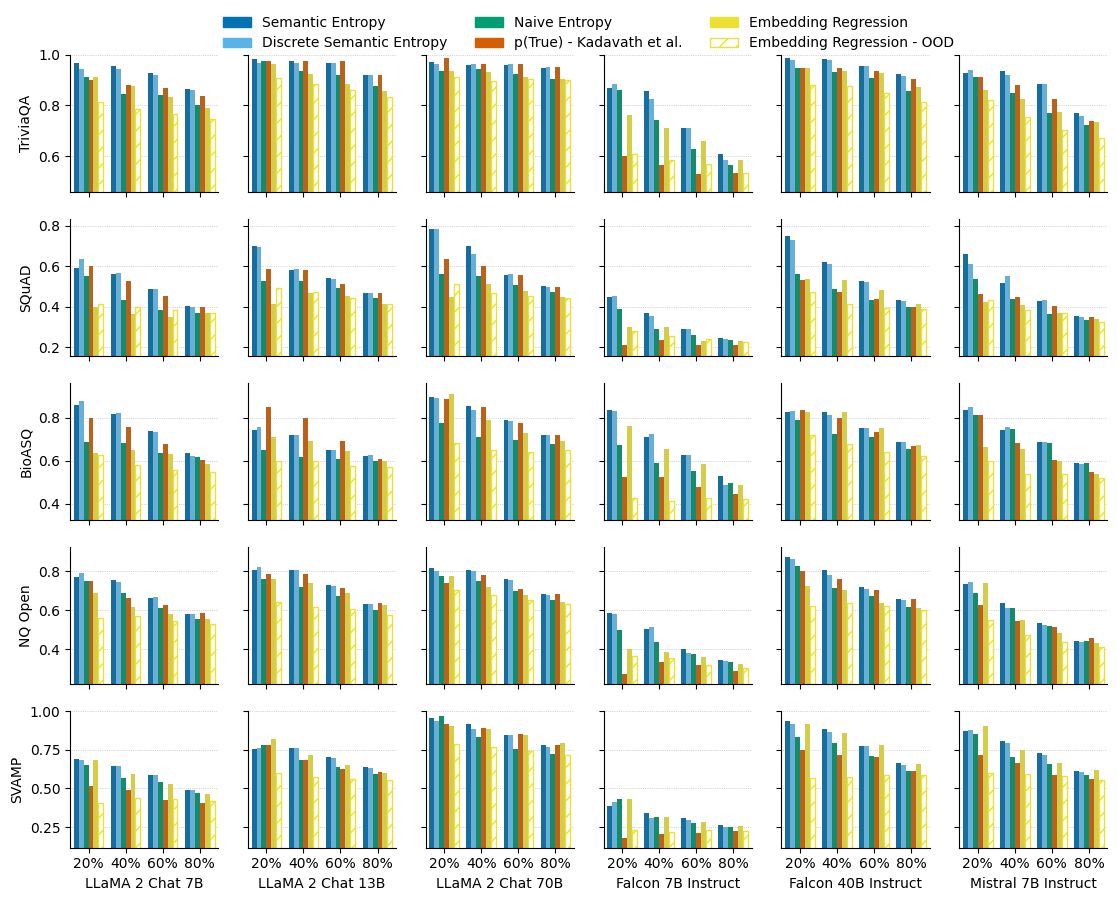

In [68]:
# Backup plot for appendix of all the rejection accuracies

# Plot for Figure 4
full_sentence_plot(entire_df,
                   datasets_in_order=['trivia_qa', 'squad', 'bioasq', 'nq', 'svamp'],
                   models_in_order=['Llama-2-7b-chat', 'Llama-2-13b-chat', 'Llama-2-70b-chat','falcon-7b-instruct', 'falcon-40b-instruct', 'Mistral-7B-Instruct-v0.1'],
                   methods_in_order = ['semantic_entropy_sum-normalized-rao', 'cluster_assignment_entropy', 'regular_entropy', 'p_false', 'p_ik', 'p_ik_ood'],
                   metrics_in_order=['accuracy_at_0.2_answer_fraction', 'accuracy_at_0.4_answer_fraction', 'accuracy_at_0.6_answer_fraction', 'accuracy_at_0.8_answer_fraction'],
                   save_path="/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/final_figures/app_sentences_rejection_accuracy_fine.pdf")


In [ ]:
def sort_dataframe_by_custom_order(df, column, order):
    """
    Sorts a copy of a DataFrame along a specified column by a specified order of keys.

    Parameters:
    df (pandas.DataFrame): The DataFrame to sort.
    column (str): The column name along which to sort.
    order (list): The specific order of keys for sorting.

    Returns:
    pandas.DataFrame: A sorted copy of the original DataFrame.
    """
    # Create a copy of the DataFrame to avoid modifying the original
    df_copy = df.copy()

    # Create a mapping of the order values to their index
    order_mapping = {key: i for i, key in enumerate(order)}

    # Assign a high number for keys not included in the order to sort them at the end
    max_index = len(order)
    df_copy['sort_order'] = df_copy[column].map(lambda x: order_mapping.get(x, max_index))

    # Sort the DataFrame copy by the temporary 'sort_order' column
    sorted_df = df_copy.sort_values('sort_order').drop('sort_order', axis=1)

    return sorted_df


plot the same, but per dataset